In [2]:
import pandas as pd

data = pd.read_csv("../Lab_5_14012026/spambase.data", header=None)

print("Dataset shape:", data.shape)
display(data.head())

X = data.iloc[:, :-1] #[:,:-1] means all cols except last
y = data.iloc[:, -1] #

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Predicting: 0 = Not Spam, 1 = Spam")

Dataset shape: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


X shape: (4601, 57)
y shape: (4601,)
Predicting: 0 = Not Spam, 1 = Spam


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc * 100, "%")
print("Confusion Matrix:\n", cm)
print(classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"]))


Accuracy: 92.94245385450597 %
Confusion Matrix:
 [[530  28]
 [ 37 326]]
              precision    recall  f1-score   support

    Not Spam       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



In [7]:
#manual evaluation metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
tnr = specificity = tn / (tn + fp)
tpr = recall = sensitivity = tp / (tp + fn)
fpr = fp/(tn + fp)

print(f"Manual Calculation of Metrics:")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Recall: {recall*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"Specificity (TNR): {tnr*100:.4f}%")
print(f"False Positive Rate (FPR): {fpr*100:.4f}%")

Manual Calculation of Metrics:
Accuracy: 92.9425%
Precision: 92.0904%
Recall: 89.8072%
F1 Score: 90.9344%
Specificity (TNR): 94.9821%
False Positive Rate (FPR): 5.0179%


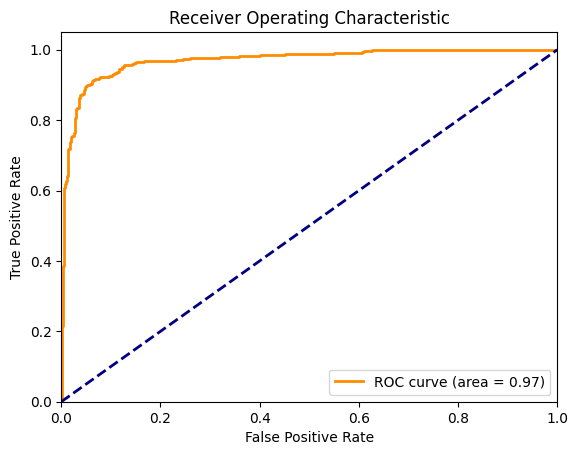

In [8]:
#roc curve and auc manual
import numpy as np
y_scores = model.decision_function(X_test)
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
# Spam Detection using Logistic Regression
plt.legend(loc="lower right")
plt.show()